<h1 align="center">ReCOR RAG</h1>

## 1. Loading all the required models

### 1.1. vLLM Wrapper

In [1]:
from langchain_core.language_models.llms import LLM
from typing import Optional, List, Mapping, Any
from pydantic import Field
import httpx, nest_asyncio
nest_asyncio.apply()
import asyncio

class VLLMWrapper(LLM):
    server_url: str = Field(default="http://vllm:8000/v1")
    model_name: str = Field(default="/model-gptoss")

    @property
    def _llm_type(self) -> str:
        return "vllm"

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        messages = [
            {"role": "system", "content": "You are a precise summarization model. Keep outputs concise and structured."},
            {"role": "user", "content": prompt}
        ]
        
        payload = {
            "model": self.model_name,
            "messages": messages,
            "temperature": 0,
            "max_tokens": 20000,
            "stop": stop,
        }
        
        response = httpx.post(f"{self.server_url}/chat/completions", json=payload, timeout=200)
        response.raise_for_status()
        
        data = response.json()
        return data['choices'][0]['message']['content']

    async def _acall(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        messages = [
            {"role": "system", "content": "You are a precise summarization model. Keep outputs concise and structured."},
            {"role": "user", "content": prompt}
        ]
        
        payload = {
            "model": self.model_name,
            "messages": messages,
            "temperature": 0.5,
            "max_tokens": 20000,
            "stop": stop,
        }
        
        async with httpx.AsyncClient() as client:
            response = await client.post(f"{self.server_url}/chat/completions", json=payload, timeout=200)
            response.raise_for_status()
            
            data = response.json()
            return data['choices'][0]['message']['content']

    async def batch_acall(self, prompts: List[str], stop: Optional[List[str]] = None) -> List[str]:
        tasks = [self._acall(prompt, stop) for prompt in prompts]
        return await asyncio.gather(*tasks)

    @property
    def _identifying_params(self) -> Mapping[str, Any]:
        return {"model_name": self.model_name}

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vllm_model = VLLMWrapper()

#### testing vllm if it's up and working

In [3]:
text = """The internet has become an indispensable tool for daily life,
revolutionizing how people access information, communicate, and conduct business.
It provides a vast repository of knowledge, enables instant global communication,
and offers a platform for e-commerce and entertainment.
However, its widespread use also presents challenges, including the spread of misinformation,
cybersecurity threats, and the risk of digital addiction"""

vllm_model.invoke(text)

'**Internet: Impact & Challenges**\n\n| Aspect | Key Points |\n|--------|------------|\n| **Benefits** | • Vast knowledge repository<br>• Instant global communication<br>• Platforms for e‑commerce & entertainment |\n| **Challenges** | • Spread of misinformation<br>• Cybersecurity threats<br>• Risk of digital addiction |'

### 1.2. Embedding Model
- BAAI bge large model

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
EMBEDDING_MODEL_NAME = "BAAI/bge-large-en-v1.5"

embeddings = HuggingFaceEmbeddings(
    model_name = EMBEDDING_MODEL_NAME,
    model_kwargs = { "device": "cuda" },
    encode_kwargs = { "normalize_embeddings": True },
)

### 1.3. FAISS Index
- consists all the 20k documents conversation summary

In [5]:
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# documents_for_faiss = [Document(page_content=doc) for doc in convert_dataset_in_strings(data)]

# documents_db = FAISS.from_documents(documents_for_faiss, embeddings)
# retriever = documents_db.as_retriever(search_kwargs={"k": 1000})

# faiss_store = FAISS.from_documents(documents_for_faiss, embeddings)
# faiss_store.save_local("faiss_index")

faiss_store = FAISS.load_local("./const/faiss_index", embeddings,allow_dangerous_deserialization=True)
retriever = faiss_store.as_retriever(search_kwargs={"k": 1000})

## 2. Implementing custom raptor class

In [6]:
RANDOM_SEED = 42
from collections import defaultdict, deque
from typing import List, Tuple, Dict, Optional
from langchain_core.prompts import ChatPromptTemplate # type: ignore
import pickle, faiss, uuid, umap # type: ignore
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

class Raptor:
    def __init__(self, docs, summariser_model, embed_model):
        self.doc = docs
        self.NODE_IDS = {}
        self.EDGES = []
        self.summariser_model = summariser_model
        self.embed_model = embed_model
        self.results = self.recursive_embed_cluster_summarize(docs, level=1, n_levels=3)
        self.ALL_NODES = {v: {"text": k, "id": v} for k, v in self.NODE_IDS.items()}
        self.adjacency, self.roots = self.build_parent_child_adjacency(self.NODE_IDS, self.EDGES)
        self.levels = self.compute_node_levels(self.adjacency)
        self.levels = self.invert_levels(self.levels)
        # Initialize node_embeddings_map here for new instances
        self.node_embeddings_map = self._create_flat_index()
        self.all_embeddings = np.array(
            [self.node_embeddings_map[nid] for nid in list(self.node_embeddings_map.keys())],
            dtype="float32"
        )
        dim = self.all_embeddings.shape[1]
        self.node_id_to_int = {nid: i for i, nid in enumerate(list(self.node_embeddings_map.keys()))}
        self.int_to_node_id = {i: nid for i, nid in enumerate(list(self.node_embeddings_map.keys()))}

        int_ids = np.array(list(self.node_id_to_int.values())).astype("int64")
        base_index = faiss.IndexFlatL2(dim)  # exact L2 search
        self.index = faiss.IndexIDMap(base_index)

        # Add embeddings with *your* IDs
        self.index.add_with_ids(self.all_embeddings, int_ids)

        print(f"FAISS index built")

    def global_cluster_embeddings(self, embeddings: np.ndarray, dim: int, n_neighbors: Optional[int] = None, metric: str = "cosine") -> np.ndarray:
        if n_neighbors is None:
            n_neighbors = int((len(embeddings) - 1) ** 0.5)
        return umap.UMAP(n_neighbors=n_neighbors, n_components=dim, metric=metric).fit_transform(embeddings)

    def local_cluster_embeddings(self, embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine") -> np.ndarray:
        return umap.UMAP(n_neighbors=num_neighbors, n_components=dim, metric=metric).fit_transform(embeddings)

    def get_optimal_clusters(self, embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED) -> int:
        max_clusters = min(max_clusters, len(embeddings))
        n_clusters = np.arange(1, max_clusters)
        bics = []
        for n in n_clusters:
            gm = GaussianMixture(n_components=n, random_state=random_state)
            gm.fit(embeddings)
            bics.append(gm.bic(embeddings))
        return n_clusters[np.argmin(bics)]

    def GMM_cluster(self, embeddings: np.ndarray, threshold: float, random_state: int = 0):
        n_clusters = self.get_optimal_clusters(embeddings)
        gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
        gm.fit(embeddings)
        probs = gm.predict_proba(embeddings)
        labels = [np.where(prob > threshold)[0] for prob in probs]
        return labels, n_clusters

    def perform_clustering(self, embeddings: np.ndarray, dim: int, threshold: float) -> List[np.ndarray]:
        import time
        start = time.time()
        if len(embeddings) <= dim + 1:
            return [np.array([0]) for _ in range(len(embeddings))]
        reduced_embeddings_global = self.global_cluster_embeddings(embeddings, dim)
        global_clusters, n_global_clusters = self.GMM_cluster(reduced_embeddings_global, threshold)
        all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
        total_clusters = 0
        for i in range(n_global_clusters):
            global_cluster_embeddings_ = embeddings[np.array([i in gc for gc in global_clusters])]
            if len(global_cluster_embeddings_) == 0:
                continue
            if len(global_cluster_embeddings_) <= dim + 1:
                local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
                n_local_clusters = 1
            else:
                reduced_embeddings_local = self.local_cluster_embeddings(
                    global_cluster_embeddings_, dim
                )
                local_clusters, n_local_clusters = self.GMM_cluster(
                    reduced_embeddings_local, threshold
                )
            for j in range(n_local_clusters):
                local_cluster_embeddings_ = global_cluster_embeddings_[np.array([j in lc for lc in local_clusters])]
                indices = np.where(
                    (embeddings == local_cluster_embeddings_[:, None]).all(-1)
                )[1]
                for idx in indices:
                    all_local_clusters[idx] = np.append(
                        all_local_clusters[idx], j + total_clusters
                    )
            total_clusters += n_local_clusters
        end = time.time()
        print(f"Clustering took {end - start} seconds")
        return all_local_clusters

    def embed(self, texts):
        text_embeddings = embeddings.embed_documents(texts)
        text_embeddings_np = np.array(text_embeddings)
        return text_embeddings_np

    def embed_cluster_texts(self, texts):
        text_embeddings_np = self.embed(texts)
        cluster_labels = self.perform_clustering(text_embeddings_np, 10, 0.1)
        df = pd.DataFrame()
        df["text"] = texts
        df["embd"] = list(text_embeddings_np)
        df["cluster"] = cluster_labels
        return df

    def fmt_txt(self, df: pd.DataFrame) -> str:
        unique_txt = df["text"].tolist()
        return "--- --- \n --- --- ".join(unique_txt)

    def embed_cluster_summarize_texts(self, texts: List[str], level: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
        df_clusters = self.embed_cluster_texts(texts)
        expanded_list = []
        for index, row in df_clusters.iterrows():
            for cluster in row["cluster"]:
                expanded_list.append({"text": row["text"], "embd": row["embd"], "cluster": cluster})
        expanded_df = pd.DataFrame(expanded_list)
        all_clusters = expanded_df["cluster"].unique()
        print(f"Generated Clusters: {len(all_clusters)}")

        # Build prompts
        template ="""Analyze the provided sub-set of conversational data transcripts. Your task is to generate a concise, highly-abstracted summary (max 300 words) that focuses only on the following:

        1.  *Causal Motifs:* What recurring conversational patterns, agent behaviors, or dialogue segments are described as leading to specific business events (e.g., escalations, refunds, churn)?
        2.  *Dialogue Dynamics:* Summarize the key structural elements of the conversation (e.g., branching flows, repeated queries, silences) that complicate analysis.
        3.  *Core Entities:* Identify and list the main operational entities, business events, or outcomes mentioned (e.g., 'refund requests,' 'escalation to supervisors').

        The goal is to provide a high-level, actionable abstraction of the data's causal content, not a detailed restatement of the transcripts.

        {context}"""
        prompt = ChatPromptTemplate.from_template(template)

        # Collect all formatted texts for clusters
        all_formatted_txts = []
        for i in all_clusters:
            df_cluster = expanded_df[expanded_df["cluster"] == i]
            formatted_txt = self.fmt_txt(df_cluster)
            prompt_txt = prompt.format(context=formatted_txt)
            all_formatted_txts.append(prompt_txt)

        # Run batch async summarisation
        summaries = asyncio.run(self.summariser_model.batch_acall(all_formatted_txts))

        df_summary = pd.DataFrame({
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        })
        return df_clusters, df_summary

    def get_id_for_text(self, text: str):
        if text not in self.NODE_IDS:
            self.NODE_IDS[text] = str(uuid.uuid4())
        return self.NODE_IDS[text]

    def recursive_embed_cluster_summarize(self, texts: List[str], level: int = 1, n_levels: int = 3) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
        results = {}
        if level == 1:
            for t in texts:
                self.get_id_for_text(t)
        df_clusters, df_summary = self.embed_cluster_summarize_texts(texts, level)
        results[level] = (df_clusters, df_summary)
        for _, row in df_summary.iterrows():
            summary_text = row["summaries"]
            summary_cluster = row["cluster"]
            summary_id = self.get_id_for_text(summary_text)
            children_df = df_clusters[df_clusters["cluster"] == summary_cluster]
            for child_text in children_df["text"].tolist():
                child_id = self.get_id_for_text(child_text)
                self.EDGES.append((child_id, summary_id))
        unique_clusters = df_summary["cluster"].nunique()
        if level < n_levels and unique_clusters > 1:
            new_texts = df_summary["summaries"].tolist()
            next_results = self.recursive_embed_cluster_summarize(new_texts, level + 1, n_levels)
            results.update(next_results)
        return results

    def build_parent_child_adjacency(self, NODE_IDS=None, EDGES=None):
        if NODE_IDS is None:
            NODE_IDS = self.NODE_IDS
        if EDGES is None:
            EDGES = self.EDGES
        adjacency = defaultdict(list)
        all_children = set()
        all_parents = set()
        for child, parent in EDGES:
            adjacency[parent].append(child)
            all_children.add(child)
            all_parents.add(parent)
        root_nodes = list(all_parents - all_children)
        return adjacency, root_nodes

    def compute_node_levels(self, adjacency=None):
        if adjacency is None:
            adjacency, _ = self.build_parent_child_adjacency()
        nodes = set(adjacency.keys())
        for children in adjacency.values():
            nodes.update(children)
        in_degree = {n: 0 for n in nodes}
        for parent, children in adjacency.items():
            for c in children:
                in_degree[c] += 1
        leaves = [n for n in nodes if n not in adjacency]
        levels = {leaf: 0 for leaf in leaves}
        reverse_adj = defaultdict(list)
        for parent, children in adjacency.items():
            for c in children:
                reverse_adj[c].append(parent)
        queue = deque(leaves)
        while queue:
            node = queue.popleft()
            node_level = levels[node]
            for parent in reverse_adj[node]:
                if parent not in levels:
                    levels[parent] = node_level + 1
                else:
                    levels[parent] = max(levels[parent], node_level + 1)
                queue.append(parent)
        return levels

    def invert_levels(self, levels: dict) -> dict:
        level_to_nodes = {}
        for node, level in levels.items():
            if level not in level_to_nodes:
                level_to_nodes[level] = []
            level_to_nodes[level].append(node)
        return level_to_nodes

    def save(self, filepath: str):
            """Saves the tree data (excluding models) to a pickle file."""
            state = {
                "doc": self.doc,
                "NODE_IDS": self.NODE_IDS,
                "EDGES": self.EDGES,
                "results": self.results,
                "ALL_NODES": self.ALL_NODES,
                "adjacency": self.adjacency,
                "roots": self.roots,
                "levels": self.levels
            }
            with open(filepath, 'wb') as f:
                pickle.dump(state, f)
            print(f"Raptor tree successfully saved to {filepath}")

    def get_leaf_nodes(self) -> List[str]:
        """Return all leaf nodes (nodes with no children)."""

        all_nodes = set(self.NODE_IDS.values())
        parent_nodes = set(self.adjacency.keys())
        leaf_nodes = all_nodes - parent_nodes

        return list(leaf_nodes)

    def filter_leaf_nodes(self, node_ids: List[str]) -> List[str]:
        """Filter only those IDs that are leaves."""
        return [
            node_id
            for node_id in node_ids
            if node_id not in self.adjacency  # no children
        ]

    def retrieve_collapsed(self, query: str, top_k: int = 10):
        # Encode query to embedding
        query_vec = self.embed_model.embed_documents([query])
        query_vec = np.array(query_vec, dtype="float32")

        # Search in FAISS
        distances, int_ids = self.index.search(query_vec, top_k)

        results = []
        for internal_id in int_ids[0]:
            if internal_id == -1:
                continue  # FAISS returns -1 if no result

            node_id = self.int_to_node_id[internal_id]
            node_data = self.ALL_NODES[node_id]

            results.append({
                "id": node_id,
                "text": node_data["text"]
            })

        return results

    def _create_flat_index(self):
        """
        Internal helper: Flattens the tree by aggregating embeddings from all levels
        into a single lookup dictionary {node_id: embedding_vector}.
        """
        node_embeddings = {}
    
        for level, (df_clusters, _) in self.results.items():
            for _, row in df_clusters.iterrows():
                text = row["text"]
                if text in self.NODE_IDS:
                    node_id = self.NODE_IDS[text]
                    node_embeddings[node_id] = row["embd"]
    
        # extract from Roots (which might be missing from results)
        for node_id, content in self.ALL_NODES.items():
            if node_id not in node_embeddings:
                emb = self.embed_model.embed_documents([content["text"]])[0]
                node_embeddings[node_id] = emb
    
        return node_embeddings

    @classmethod
    def load(cls, filepath: str, summariser_model, embed_model):
          """Loads the tree data and re-attaches new model instances."""

          with open(filepath, 'rb') as f:
              state = pickle.load(f)

          # blank instance (Bypass __init__ to avoid rebuilding)
          instance = cls.__new__(cls)

          # restoring old previous state
          instance.doc = state["doc"]
          instance.NODE_IDS = state["NODE_IDS"]
          instance.EDGES = state["EDGES"]
          instance.results = state["results"]
          instance.ALL_NODES = state["ALL_NODES"]
          instance.adjacency = state["adjacency"]
          instance.roots = state["roots"]
          instance.levels = state["levels"]


          instance.summariser_model = summariser_model
          instance.embed_model = embed_model

          # Explicitly initialize node_embeddings_map after loading
          instance.node_embeddings_map = instance._create_flat_index()

          return instance

## 3. Chat Bot

### 3.1. Chat bot state

In [7]:
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage

class SubQueryResult(TypedDict):
    """Represents the result of a single sub-query."""

    node_ids: list[str]
    sub_query: str

class ChatState(TypedDict):
    """The state of the conversational graph"""

    # All the messages AI and User
    messages: Annotated[list[BaseMessage], add_messages]

    # Sub-Queries of last question
    unique_query: str
    sub_queries: list[SubQueryResult]
    sub_queries_context: str
    raptor: object
    plan_string: str
    evidence: Dict[str, str]  # Stores #E1: "content", #E2: "content"
    summary: str
    node_ids: list[str]

### 3.2. Colbert Reranker Implementation

In [8]:
from typing import List, Dict, Any, Union
from langchain_core.documents import Document as LCDocument

def convert_dataset_in_strings(data: List[Union[Dict[str, Any], LCDocument]]) -> List[str]:
    """
    Creates a list of strings combining metadata and summary text,
    handles both raw dicts and LangChain Document objects.
    """
    final_reranking_documents: List[str] = []

    for item in data:
        if isinstance(item, LCDocument):
            # For LangChain Document objects, just extract page content
            full_document_string = item.page_content
            final_reranking_documents.append(full_document_string)
            continue

        metadata_header = (
            f"[Domain]: {item.get('domain', '')} "
            f"[Intent]: {item.get('intent', '')} "
            f"[Reason]: {item.get('reason_for_call', '')}\n"
            f"[Id]: {item.get('transcript_id', '')}"
        )

        summary = item.get("summary", "")

        full_document_string = f"{metadata_header}\n---\n{summary}"
        final_reranking_documents.append(full_document_string)

    return final_reranking_documents

In [9]:
from typing import List, Union
import sys
import types
from langchain_core.documents.compressor import BaseDocumentCompressor

fake_module = types.ModuleType("langchain.retrievers.document_compressors.base")
fake_module.BaseDocumentCompressor = BaseDocumentCompressor

sys.modules["langchain.retrievers.document_compressors.base"] = fake_module
from ragatouille import RAGPretrainedModel

checkpoint = 'colbert-ir/colbertv2.0'
RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

# using golbally defined RAG
def colbert_reranker(query: str, documents: List[Union[str, dict]], k: int = 5, reranker_model: RAGPretrainedModel = RAG) -> List[dict]:
    """
    Reranks a list of retrieved documents using the pre-trained RAGatouille (ColBERT) model.

    Args:
        query (str): The search query string.
        documents (List[Union[str, dict]]): The list of documents (strings or dicts
                                            containing 'content' field) retrieved
                                            by the initial retrieval pipeline.
        k (int): The number of top-ranked documents to return.
        reranker_model (RAGPretrainedModel): The initialized RAGatouille model instance.

    Returns:
        List[dict]: A list of dictionaries containing the reranked documents, their
                    ColBERT scores, and their ranks.
    """
    if not isinstance(documents[0], str) and 'content' in documents[0]:
        documents_for_reranker = [doc['content'] for doc in documents]
    else:
        documents_for_reranker = documents

    # Perform the re-ranking using the RAGatouille instance
    return reranker_model.rerank(query=query, documents=documents_for_reranker, k=k)

/tmp/ipykernel_45/4003754954.py:10: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel
/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


### 3.3. ReWOO Implementation

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Annotated, List, Dict
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
import re

In [11]:
PLANNER_PROMPT = ChatPromptTemplate.from_template("""
You are an expert retrieval PLANNER for a Retrieval-Augmented Generation (RAG) system.
Your job: convert a user question (which may be a follow-up) + a conversation summary into a compact, precise retrieval plan — the minimal sequence of evidence-gathering steps needed so a separate reader/synthesizer can answer the user correctly.

Inputs you receive:
- User Question: {question}
- Conversation Summary: {summary}

Primary objectives (in order):
1. If the user's question relies on or refers to prior context, rewrite/normalize the question so it is self-contained using information found in the summary.
2. Produce a minimal set of retrieval steps that together gather all evidence required to answer the normalized question.
3. Ensure each retrieval step yields verifiable evidence (#E1, #E2, ...), uses the correct tool, and uses a self-contained, specific query string.

Available Tools:
- Raptor[query]: search the document index. Use for any targeted factual lookup (documents, terms, logs, receipts, policies, timestamps, etc).
- LLM[context]: use only to (a) resolve ambiguous references using the provided summary, (b) produce final synthesis or complex computation (but do not use for simple lookups), or (c) normalize/expand the user's question into a self-contained question.

Output format (strict):
NormalizedQuestion: <A single self-contained sentence that fully captures the user's intent and any references resolved using the summary.>
Plan: <Short description of step> #E[StepNum] = ToolName[ToolInput]
... (one Plan line per step, ordered)

Mandatory constraints (follow exactly):
- Combine related variables into a single search. Example: search "Event details" rather than separate searches for Date, Time, Location.
- Use LLM[context] only for disambiguation of ambiguous references or for final synthesis/complex calculations — not for simple retrievals.
- Each step must produce an evidence token (#E1, #E2, ...).
- Retrieval queries must be specific, self-contained, and executable without prior steps (unless they reference a previous evidence tag like #E1 when necessary).
- Do not hallucinate. If the summary lacks the necessary info to form a specific query, use LLM[context] to infer the reference with explicit justification, or create a step to fetch clarifying evidence.

Rules for writing queries:
- Prefer concrete names, identifiers, time ranges, and exact phrases from the summary.
- If the user says “the last company we talked about,” first resolve that to a named entity using LLM[context] referencing the summary, then use Raptor for facts about that entity.
- Use boolean-style, self-contained queries when helpful (e.g., "Lily Kelly promotional code 'SPRING2025' terms and multi-room booking").
- Do not include placeholders like <NAME> in Raptor queries — resolve them first.


Followings are the examples for you to get an idea of how to plan according to the query, only take it as an example( It has nothing to do with the queries you will get for generation) :-

1) Follow-up example
User: "Find out which promotional code Lily Kelly inquired about and check if that specific code allows for booking multiple rooms."
Summary: Lily Kelly asked about code SPRING2025 in earlier messages.
Output:
NormalizedQuestion: Which promotional code did Lily Kelly ask about (SPRING2025) and does that code permit booking multiple rooms?
Plan: Identify the promotional code referenced for Lily Kelly (confirm code). #E1 = LLM[Confirm that Lily Kelly's inquiry in summary refers to 'SPRING2025']
Plan: Fetch the official terms and conditions for the code SPRING2025. #E2 = Raptor["SPRING2025 terms and conditions multi-room booking"]

2) Ambiguous reference example
User: "Compare revenue of Company A, Company B and the last company we talked about in 2023."
Summary: The conversation referenced Company C and Company D; the last company discussed was Company C.
Output:
NormalizedQuestion: Compare 2023 revenues for Company A, Company B, and Company C (Company C identified from the summary as the last company discussed).
Plan: Fetch Company A revenue 2023. #E1 = Raptor["Company A revenue 2023"]
Plan: Fetch Company B revenue 2023. #E2 = Raptor["Company B revenue 2023"]
Plan: Fetch Company C revenue 2023. #E3 = Raptor["Company C revenue 2023"]


Final note:
- Do not answer the question here. Only output the NormalizedQuestion and the ordered Plan lines with evidence tags.
- Keep queries actionable and minimal. Always prefer merging searches where it reduces steps without losing precision.
""")

def planner_node(state: ChatState):
    question = state["messages"][-1].content
    summary = state["summary"]

    chain = PLANNER_PROMPT | vllm_model

    # Generate the blueprint
    result = chain.invoke({"question": question,"summary": summary})
    return {"plan_string": result}

In [12]:
SOLVER_PROMPT = ChatPromptTemplate.from_template("""
You are an expert incident analyst.
Your job is to produce a grounded, evidence-based causal explanation using ONLY the Original Question, the Summary, and the Plan & Retrieved Evidence (multiple context items).

You must analyze ALL retrieved contexts collectively and perform aggregated inference across them:
- Identify patterns or repeated behaviors.
- Count how many evidence items support each insight.
- Compute approximate percentages when possible.
  Example: “6 out of 20 contexts (~30%) mention X.”
- NEVER invent information not present in the evidence.
- If evidence is insufficient, state it clearly.

If no relevant evidence exists:
RETURN: REQUIRED INFO IS NOT PRESENT

You MUST follow this exact output structure:

Final Answer:

- **Direct Answer:**
A concise conclusion directly answering the question, grounded ONLY in the contexts. No speculation.

- **Key Incidents from Evidence:**
List specific incidents, facts, statements, or events explicitly described in the evidence.
Do NOT reference item numbers. Summarize only what is actually stated.

- **Causal Explanation:**
Explain WHY the outcome in the question occurred, based strictly on reasons or hints present in the evidence.
No invented causal chains.

- **Cross-Evidence Patterns (Aggregated Inference):**
Identify patterns, trends, or repeated behaviors visible across the evidence.
Include counts and approximate percentages:
Example:
- “5 contexts (~25%) describe delays.”
- “7 contexts (~35%) mention misunderstanding policy terms.”

- **Contradictions or Missing Information:**
List inconsistencies between evidence items OR highlight gaps that prevent a full causal explanation.

- **Consolidated Interpretation:**
A short paragraph synthesizing all incidents, aggregated evidence, and causal reasoning into a final, unified causal interpretation answering the user’s query.

Rules:
- Do NOT mention evidence item numbers.
- Do NOT hallucinate missing details.
- ONLY use provided contexts.
- Aggregate evidence across all contexts before concluding.

Inputs:
Original Question: {question}
Summary: {summary}
Plan & Evidence:
{plan_evidence}

Final Answer:
""")

def solver_node(state: ChatState):
    plan_string = state["plan_string"]
    evidence = state["evidence"]
    question = state["messages"][-1].content

    # Reconstruct the plan with the actual evidence attached
    # We replace the placeholder #E1 lines with the actual text found
    full_context = ""
    regex_pattern = r"(#E\d+)\s*=\s*(\w+)\s*\[([^\]]+)\]"

    # Split plan into lines to reconstruct it clearly for the Solver
    for line in plan_string.split('\n'):
        if "=" in line:
            match = re.search(regex_pattern, line)
            if match:
                step_id = match.group(1)
                if step_id in evidence:
                    full_context += f"{line}\nRESULT: {evidence[step_id]}\n---\n"
                else:
                    full_context += f"{line}\nRESULT: No evidence found.\n---\n"
        else:
            full_context += f"{line}\n"

    chain = SOLVER_PROMPT | vllm_model

    final_answer = chain.invoke({"question": question, "plan_evidence": full_context, "summary": state["summary"]})
    return {"messages": [final_answer]}

In [13]:
def worker_node(state: ChatState):
    plan_string = state["plan_string"]
    raptor = state["raptor"]
    summary = state['summary']
    evidence = {}

    # Regex to capture: (Description) (#E_id) (Tool) (Input)
    regex_pattern = r"Plan:\s*(.+?)\s*(#E\d+)\s*=\s*(\w+)\s*\[([^\]]+)\]"
    matches = re.findall(regex_pattern, plan_string)
    node_ids = set()
    for match in matches:
        description, step_id, tool, tool_input = match
        print(f"Executing {step_id}: {tool}[{tool_input}]")

        # --- 1. RESOLVE VARIABLES ---
        # Replace #E variables with their actual content string
        resolved_input = tool_input
        context_dependency_exists = False

        for prev_id, prev_text in evidence.items():
            if prev_id in resolved_input:
                resolved_input = resolved_input.replace(prev_id, prev_text)
                context_dependency_exists = True

        # --- 2. EXECUTE TOOL ---
        if tool == "Raptor":
            search_query = resolved_input

            #  Context Distillation
            if context_dependency_exists:
                extraction_prompt = f"""
                You are a Search Query Optimizer for a retrieval system.
                Your goal is to extract the key entities and intent from the 'Context' to answer the 'Task'.

                Rules:
                1. Prioritize SPECIFIC ENTITIES (Names, IDs, Promo Codes, Error Messages).
                2. Discard conversational filler (e.g., "The agent said", "The customer asked").
                3. The query must be short (5-10 words) and optimized for vector search.
                4. Output ONLY the query string.

                ---
                Example 1:
                Task: Search for the terms of #E1
                Context: "The customer Lily Kelly mentioned she is using the Summer20 promo code for her booking..."
                Distilled Query: Summer20 promo code terms and conditions

                Example 2:
                Task: Identify the resolution for #E1
                Context: "Issue: Double booking error for Jack Bell (bk-12345). The agent offered a refund..."
                Distilled Query: Jack Bell double booking resolution refund
                ---

                Current Task: {description}
                Context: {resolved_input[:3000]}...

                Distilled Query:"""

                # Use your fast planner LLM (Llama-3-8B) for this translation
                query_msg = vllm_model.invoke(extraction_prompt)
                search_query = query_msg.strip().replace('"', '')
                print(f"  -> Distilled Query: {search_query}")

            # Retrieve using the clean query
            nodes = raptor.retrieve_collapsed(search_query, top_k=10)
            node_ids_match = [node["id"] for node in nodes]
            node_ids.update(node_ids_match)
            context_text = "\n".join([f"- {n['text']}" for n in nodes])
            evidence[step_id] = context_text

        elif tool == "LLM":
            # LLM tool can handle the large text directly for synthesis
            msg = f"{description}\n\nInput Context:\n{resolved_input} More Context:\n{summary}"
            response = vllm_model.invoke(msg)
            evidence[step_id] = response

    return {"evidence": evidence, "node_ids" : list(node_ids)}

### 3.4. Summary 2

In [14]:
SUMMARY_PROMPT = ChatPromptTemplate.from_template("""
You are an expert conversation summarizer for a RAG system.

Your job is to maintain a **natural, flowing summary of the conversation** that:
- Feels like a real recap of the dialogue between the user and the assistant.
- Captures the key points, intentions, clarifications, and ongoing topics.
- Preserves context that will matter for future questions.
- Prioritizes the most recent exchange while compressing older ones.
- Never invents information not present in the inputs.
- Stays under 256 tokens.

Guidelines:
1. Keep the tone neutral and narrative, as if recapping what happened so far.
2. Maintain the *conversation flow*:
   - What the user asked or wanted
   - What the assistant explained or attempted
   - Any follow-ups, unresolved tasks, or shifts in topic
3. Retain earlier context only if it is still relevant to the current direction.
4. The summary should read like:
     “The user initially asked X. The assistant explained Y. Later, the user moved
      to Z, and the assistant responded with… Recently, the discussion shifted to…”
   Not like a bullet list of facts.
5. Do not quote entire messages — condense them meaningfully.
6. Include only information found in either the existing summary, the latest query, or the latest answer.

Inputs:

Existing Summary:
{summary}

Latest User Query:
{query}

Latest Assistant Answer:
{answer}

Return ONLY the updated conversation-style summary.

""")

def summary_gen2(state: ChatState):
    summary = state.get("summary", "")
    query = str(state["messages"][-2].content).strip()
    answer = str(state["messages"][-1].content).strip()

    # If no previous summary, just initialize with the first query
    if not summary:
        summary = query

    # Prepare prompt
    prompt = SUMMARY_PROMPT.format(summary=summary, query=query, answer=answer)

    # Call your model (example: state["llm"])
    state["summary"] = vllm_model.invoke(prompt).strip()
    
    return {**state}

### 3.5. Summary 1

In [15]:
query_rewrite_prompt = ChatPromptTemplate.from_template("""
You are an expert **Query Rewriter** for a RAG system.

You are given:
1. A conversation summary (short, distilled state of the dialog so far).
2. The user's latest raw query.

Your task:
- Rewrite the query so that it becomes fully **self-contained**, **unambiguous**, and
  **contextually complete**.
- If the latest query depends on previous conversation context, incorporate only the
  **relevant parts** of the summary.
- If the query is independent, keep it mostly unchanged but clarify ambiguous pronouns or references.
- If the user uses “they”, “it”, “that issue”, “the previous one”, etc., resolve them using the summary.
- The rewritten query must be:
    - Context-complete
    - Precise
    - Neutral tone
    - Free from hallucination
    - Not longer than necessary

Strict rules:
1. Do **not** add information not present in either the summary or the new query.
2. Do **not** repeat irrelevant earlier details; pull only context necessary for making the query self-contained.
3. Eliminate ambiguity — all entities, events, and references must be explicit.
4. Return only **one sentence or short paragraph** containing the rewritten query.
5. Do not include explanation, reasoning, or meta text.

Inputs:

Summary:
{summary}

User Query:
{query}

Return **ONLY** the rewritten query.

""")

def summary_gen(state: ChatState):
    summary = state.get("summary", "")
    query = str(state["messages"][-1].content).strip()

    # If no summary exists, nothing to rewrite → use query as-is
    if not summary:
        new_query = query
    else:
        prompt = query_rewrite_prompt.format(summary=summary, query=query)
        new_query = vllm_model.invoke(prompt).strip()
        
    state["messages"][-1] = HumanMessage(content=new_query)
    return {**state}

### 3.5. Make Raptor Node

In [16]:
RERANK_K = 100

def make_raptor(state: ChatState):
  query = str(state["messages"][-1].content.strip())
  raw_documents = retriever.invoke(query, k=1000)

  # Extract just the content text as a list of strings
  candidate_documents: List[str] = [document for document in raw_documents]
  print(f"Retrieved {len(candidate_documents)} initial candidate documents.")

  reranked_results = colbert_reranker(query=query, documents=convert_dataset_in_strings(candidate_documents), k=RERANK_K)
  # prepare final Document Set for Raptor
  # extracting the content from the highly-ranked results
  final_docs_for_raptor: List[str] = [item['content'] for item in reranked_results]

  print(f"Selected {len(final_docs_for_raptor)} documents after ColBERT reranking.")

  return {**state,"raptor": Raptor(final_docs_for_raptor, vllm_model, embeddings)}

### 3.6. Chat Bot Graph

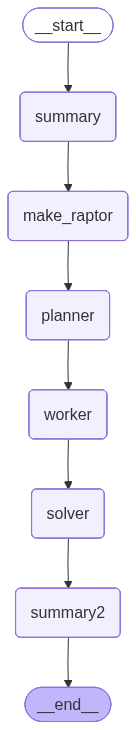

In [17]:
# Graph Construction
rewoo_graph = StateGraph(ChatState)

# Add Nodes (ONLY Planner, Worker, Solver)
rewoo_graph.add_node("summary", summary_gen)
rewoo_graph.add_node("make_raptor", make_raptor)
rewoo_graph.add_node("planner", planner_node)
rewoo_graph.add_node("worker", worker_node)
rewoo_graph.add_node("solver", solver_node)
rewoo_graph.add_node("summary2", summary_gen2)

# Add Edges
rewoo_graph.add_edge(START, "summary")
rewoo_graph.add_edge("summary", "make_raptor")
rewoo_graph.add_edge("make_raptor", "planner")
rewoo_graph.add_edge("planner", "worker")
rewoo_graph.add_edge("worker", "solver")
rewoo_graph.add_edge("solver", "summary2")
rewoo_graph.add_edge("summary2", END)

# Compile
rewoo_bot = rewoo_graph.compile()
rewoo_bot

## 4. Calling Chat Bot

### 4.1. function to get leaves nodes from raptor

In [18]:
def get_leaf_nodes(node_ids, adj):
    """
    Given a list of node_ids and an adjacency list (directed graph),
    return all unique leaf nodes reachable from these node_ids.

    A leaf node = node with no outgoing edges.
    """

    visited = set()
    leaf_nodes = set()

    def dfs(node):
        # Prevent revisiting
        if node in visited:
            return
        visited.add(node)

        # If node is not in adj OR has empty children → it's a leaf
        if node not in adj or not adj[node]:
            leaf_nodes.add(node)
            return

        # Otherwise, visit children
        for child in adj[node]:
            dfs(child)

    # Run DFS for each starting node
    for n in node_ids:
        dfs(n)

    return list(leaf_nodes)

### 4.2. Chat Bot Wrapper

In [19]:
import time

class ChatBot:
    def __init__(self):
        self.thread = "1"
        self.summary = ""
        
    def call(self,query: str):
        start_time = time.time()
        out = rewoo_bot.invoke({"messages": [HumanMessage(content=query)],"summary" : self.summary})
        
        print("Answer is generated !!")
        
        answer = out['messages'][-1].content
        summary = out['summary']
        self.summary = summary
        node_ids = out['node_ids']
        ALL = out['raptor'].ALL_NODES
        adjacency = out['raptor'].adjacency
        leaf_nodes = get_leaf_nodes(node_ids, adjacency)
        unique_text = [ALL[i] for i in node_ids]
        leave_text = [ALL[i] for i in leaf_nodes]
        end_time = time.time()
        
        return {"answer": answer, "node_ids": node_ids, "unique_text": unique_text, "leave_text": leave_text,"query": query, "time": (end_time-start_time)}

In [20]:
bot = ChatBot()

In [21]:
out = bot.call("why hotel bookings get cancel?")

Retrieved 1000 initial candidate documents.


/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|██████████| 32/32 [00:01<00:00, 29.34it/s]


Selected 100 documents after ColBERT reranking.
Clustering took 11.228732824325562 seconds
Generated Clusters: 22
Clustering took 0.44214892387390137 seconds
Generated Clusters: 6
Generated Clusters: 1
FAISS index built
Executing #E1: Raptor["hotel booking cancellation reasons"]
Answer is generated !!


In [28]:
print("ReCOR RAG response : ", out["answer"])

ReCOR RAG response :  **Final Answer:**

- **Direct Answer:**  
  Hotel bookings are canceled mainly because guests are dissatisfied with service quality, find better prices or locations elsewhere, or are unhappy with the hotel’s cancellation policies and fees.

- **Key Incidents from Evidence:**  
  - A guest cited slow, unhelpful staff as the reason for cancellation.  
  - Several guests canceled because they found cheaper or more convenient options at competitors such as Hilton or Marriott.  
  - A customer objected to the hotel’s restrictive cancellation policy and the high fees for last‑minute cancellations.  
  - One guest wanted to cancel due to an unforeseen circumstance and was offered a partial fee reduction.  
  - A customer was offered a discount to keep the booking but ultimately chose to cancel.

- **Causal Explanation:**  
  The cancellations occur when the perceived value of staying (service quality, price, location, or flexibility) falls below the guest’s expectations 

In [29]:
print("ReCOR RAG response time (in seconds) : ", out["time"])

ReCOR RAG response time (in seconds) :  58.571229219436646


## 5. Fetching Turns

In [23]:
from typing import List, Optional
import json

with open("./const/summaries-20k.json", "r") as f:
    data = json.load(f)

convos_by_id = {c["transcript_id"]: c for c in data}

def extract_transcript_ids(document_texts: List) -> List[Optional[str]]:
    """
    Handle list items that may be dicts or strings.
    Extracts: [Id]: <uuid>
    """
    pattern = re.compile(
        r'\[Id\]:\s*([a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12})',
        re.IGNORECASE
    )

    ids = []
    for item in document_texts:
        # If dict, extract its "text" field
        if isinstance(item, dict):
            text = item.get("text", "")
        else:
            text = str(item)

        m = pattern.search(text)
        ids.append(m.group(1) if m else None)

    return ids

async def extract_single_convo(query: str, conversation, transcript_id: str):
    convo_text = ""
    for turn_id, turn in enumerate(conversation):
        speaker = turn.get("speaker", "")
        text = turn["text"]
        convo_text += f"Turn {turn_id}: {speaker}: {text}\n"

    prompt = f"""
    Query: {query}

    Full conversation:
    {convo_text}

    INSTRUCTIONS:
    1. Find turns relevant to the query
    2. Return ONLY the top 5 turn numbers, comma-separated

    Example output: 5,8,12,15,23

    Turn numbers:
    """

    messages = [
        {"role": "system", "content": "Return ONLY comma separated turn numbers, no extra text."},
        {"role": "user", "content": prompt},
    ]

    payload = {
        "model": vllm_model.model_name,
        "messages": messages,
        "temperature": 0,
        "max_tokens": 1000,
    }

    async with httpx.AsyncClient(timeout=100) as client:
        resp = await client.post(f"{vllm_model.server_url}/chat/completions", json=payload)
        resp.raise_for_status()
        resp_json = resp.json()
        try:
            content = resp_json["choices"][0]["message"]["content"]
        except (KeyError, IndexError, TypeError):
            content = None

        if content is None or not content.strip():
            return {
                "transcript_id": transcript_id,
                "turn_numbers": [],
                "relevant_turns": [],
            }

        out = content.strip()

    turns = [int(x.strip()) for x in out.split(",") if x.strip().isdigit()]
    valid_turns = [t for t in turns if 0 <= t < len(conversation)]
    relevant_turns = [
        {
            "turn_index": t,
            "speaker": conversation[t].get("speaker", ""),
            "text": conversation[t].get("text", ""),
        }
        for t in valid_turns[:5]
    ]

    return {
        "transcript_id": transcript_id,
        "turn_numbers": valid_turns[:5],
        "relevant_turns": relevant_turns,
    }

async def extract_from_multiple_transcripts(query: str, transcript_ids: list):
    tasks = []
    for tid in transcript_ids:
        convo = convos_by_id.get(tid)
        if convo:
            tasks.append(extract_single_convo(query, convo["conversation"], tid))

    results = await asyncio.gather(*tasks)
    return results

def get_evidence(bot_output):
    query = bot_output.get("query", "")
    unique_text = bot_output.get('leave_text', [])
    transcript_ids = extract_transcript_ids(unique_text)
    
    return asyncio.run(extract_from_multiple_transcripts(query, transcript_ids))

In [24]:
evidence = get_evidence(out)

In [25]:
evidence[0]

{'transcript_id': 'e2c82bd8-f526-4785-bee5-f8a77e50adad',
 'turn_numbers': [2, 8, 12, 14, 22],
 'relevant_turns': [{'turn_index': 2,
   'speaker': 'Agent',
   'text': "i'm sorry uh to hear that noah may i um know the reason for the cancellation"},
  {'turn_index': 8,
   'speaker': 'Agent',
   'text': 'i see definitely understandable let me explain our uh cancellation policy for you'},
  {'turn_index': 12,
   'speaker': 'Agent',
   'text': 'alright um it looks like there’s a cancellation fee you know due to the timing which is actually um fifteen percent of like the total'},
  {'turn_index': 14,
   'speaker': 'Agent',
   'text': 'i’m sorry noah just to reassure you you will still receive the remaining balance um after that fee'},
  {'turn_index': 22,
   'speaker': 'Agent',
   'text': 'understood i’ll process the cancellation um now just a moment please'}]}